<a href="https://colab.research.google.com/github/FranciscoDegiovani/ml-classification-breast-cancer/blob/main/ml_classification_breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading the data

Using the built-in scikit-learn dataset instead of downloading anything — it's the Breast Cancer Wisconsin dataset, 569 samples with 30 numeric features extracted from digitized biopsy images, plus a binary target (malignant/benign).

## Checking class balance and missing values

Before training anything, want to know if the classes are balanced and if there's any missing data to deal with.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f"Shape: {df.shape}")
print(f"Classes: {dict(zip(data.target_names, [0, 1]))}")
df.head()

Shape: (569, 31)
Classes: {np.str_('malignant'): 0, np.str_('benign'): 1}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(3))
print(f"\nMissing values: {df.isnull().sum().sum()}")

target
1    357
0    212
Name: count, dtype: int64
target
1    0.627
0    0.373
Name: proportion, dtype: float64

Missing values: 0


## Train/test split

Splitting before doing anything else with the data, so the test set stays untouched until final evaluation — avoids leaking information from test into training.

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Train: 455 samples | Test: 114 samples


## Feature scaling

Logistic regression is sensitive to feature scale — some columns here range from 0.05 to over 2000, so standardizing puts everything on comparable footing before training.

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Training a baseline model

Starting with logistic regression as a baseline — simple, interpretable, and a good reference point before trying anything more complex.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(random_state=42, max_iter=5000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\n", classification_report(y_test, y_pred, target_names=['malignant', 'benign']))

Accuracy: 0.982

               precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Confusion matrix

Numbers are good, but a confusion matrix makes it easier to see exactly where the model is right or wrong.

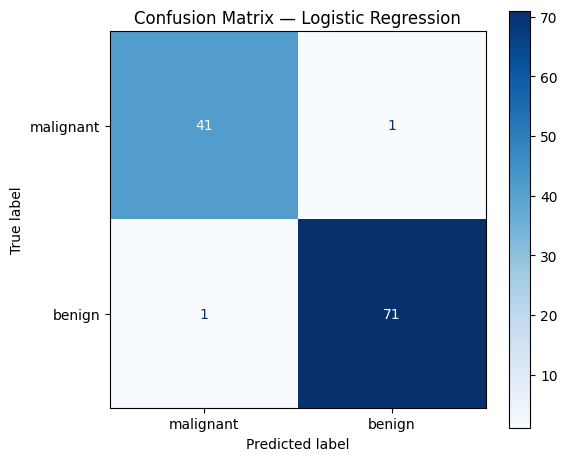

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['malignant', 'benign'], cmap='Blues', ax=ax
)
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix_logreg.png', dpi=150)
plt.show()

## Comparing with Random Forest

Logistic regression is linear — trying a Random Forest next to see if a non-linear model captures the pattern better, and because it gives feature importance for free.

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, n_estimators=200)
rf_model.fit(X_train, y_train)  # tree-based models don't need scaling

y_pred_rf = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print("\n", classification_report(y_test, y_pred_rf, target_names=['malignant', 'benign']))

Accuracy: 0.956

               precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Feature importance

Random Forest naturally ranks which features mattered most for its predictions — useful to check if it lines up with what's biologically expected (larger, more irregular cells tend to be malignant).

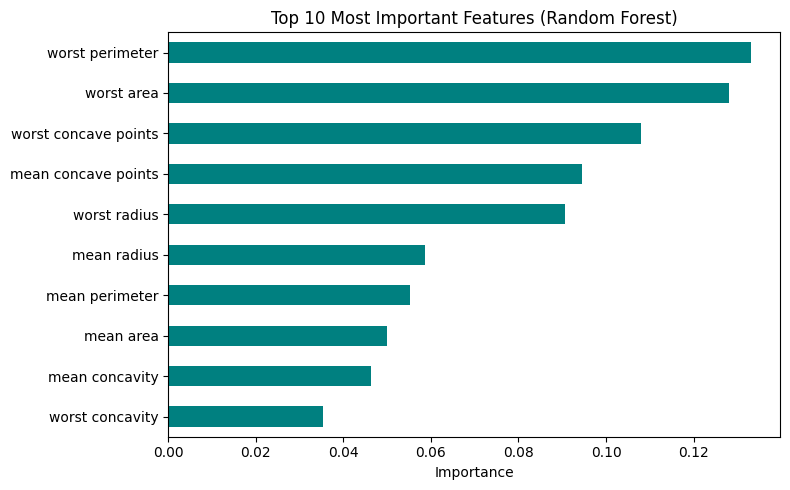

In [8]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150)
plt.show()

## Cross-validation

A single train/test split can be lucky or unlucky depending on which samples ended up in the test set. Cross-validation trains and tests the model 5 times on different splits of the data, giving a more reliable estimate of real performance.

In [9]:
from sklearn.model_selection import cross_val_score

X_scaled_full = scaler.fit_transform(X)  # scale the whole dataset for CV

cv_scores_logreg = cross_val_score(LogisticRegression(random_state=42, max_iter=5000), X_scaled_full, y, cv=5)
cv_scores_rf = cross_val_score(RandomForestClassifier(random_state=42, n_estimators=200), X, y, cv=5)

print(f"Logistic Regression — CV accuracy: {cv_scores_logreg.mean():.3f} (+/- {cv_scores_logreg.std():.3f})")
print(f"Random Forest       — CV accuracy: {cv_scores_rf.mean():.3f} (+/- {cv_scores_rf.std():.3f})")

Logistic Regression — CV accuracy: 0.981 (+/- 0.007)
Random Forest       — CV accuracy: 0.958 (+/- 0.024)


## ROC curve

Accuracy alone doesn't show how the model performs across different decision thresholds. The ROC curve and AUC score give a fuller picture, especially relevant in a medical context where the cost of a false negative is high.

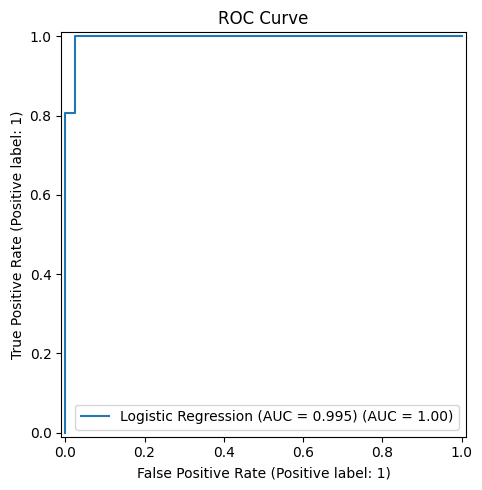

In [10]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

y_proba_logreg = model.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_proba_logreg)

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_logreg, ax=ax, name=f'Logistic Regression (AUC = {auc:.3f})')
plt.title('ROC Curve')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

## Final conclusion

Cross-validation confirms the single-split results: logistic regression averages 98.1% accuracy (± 0.7%) across 5 folds, more consistent than Random Forest (95.8% ± 2.4%). Combined with an AUC of 0.995, this indicates the classes are close to linearly separable and a simple, interpretable model performs as well as a more complex one — a good example of not over-engineering when the simpler solution already works. Given these results, logistic regression is the model I'd take forward as the final choice.